#### Abstract

This notebook analyzes accident flight trace data from ADBS.LOL (https://www.adsb.lol/), covering the period from 2023 to the present with daily updates. These records contain detailed flight-level information, enabling insights into aircraft behavior and event patterns. In this notebook, we conduct descriptive analysis to explore distributions, trends, and structural differences characteristics. The analysis provides an initial overview of the data and establishes a basis for further investigation.

In [2]:

from paths import *
import pandas as pd
import duckdb

from src.common.plots import *
from src.common.data_integrity import *

In [6]:
CRASH_PATH  = PARQUET_TRACES_CRASH / "traces_00.pq"
#NO_CRASH_PATH = PARQUET_TRACES_NO_CRASH / "*.pq"

In [7]:
con = duckdb.connect()

##### Outlier Detection

In [8]:
con.sql(f"""
SELECT
    -- Altitude: -500 to 45,000 ft
    ROUND(SUM(CASE WHEN trace.altitude < -500 OR trace.altitude > 45000 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_alt_outliers,
    ROUND(SUM(CASE WHEN trace.geometric_altitude < -500 OR trace.geometric_altitude > 45000 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_geom_alt_outliers,
    
    -- Ground speed / IAS: > 600 kt
    ROUND(SUM(CASE WHEN trace.ground_speed > 600 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_gs_outliers,
    ROUND(SUM(CASE WHEN trace.indicated_airspeed > 600 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_ias_outliers,
    
    -- Vertical rate: +/- 6,000 ft/min
    ROUND(SUM(CASE WHEN trace.vertical_rate < -6000 OR trace.vertical_rate > 6000 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_vr_outliers,
    ROUND(SUM(CASE WHEN trace.geometric_vertical_rate < -6000 OR trace.geometric_vertical_rate > 6000 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_geom_vr_outliers,
    
    -- Track degrees: [0, 360)
    ROUND(SUM(CASE WHEN trace.track_degrees < 0 OR trace.track_degrees >= 360 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_track_outliers,
    
    -- Roll angle: +/- 60 degrees
    ROUND(SUM(CASE WHEN trace.roll_angle < -60 OR trace.roll_angle > 60 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_roll_outliers,
    
    -- Lat/Lon
    ROUND(SUM(CASE WHEN trace.lat < -90 OR trace.lat > 90 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_lat_outliers,
    ROUND(SUM(CASE WHEN trace.lon < -180 OR trace.lon > 180 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_lon_outliers,
    
    COUNT(*) AS total_rows
FROM parquet_scan('{CRASH_PATH}')
""").df()

,pct_alt_outliers,pct_geom_alt_outliers,pct_gs_outliers,pct_ias_outliers,pct_vr_outliers,pct_geom_vr_outliers,pct_track_outliers,pct_roll_outliers,pct_lat_outliers,pct_lon_outliers,total_rows
0,0.01,0.03,0.11,0.0,0.02,0.01,0.0,0.0,0.0,0.0,961727


With more conservative thresholds applied, outlier rates remain very low across all fields (max 0.12% for `ground_speed`). The most notable outliers appear in `ground_speed`, `geometric_altitude`, `vertical_rate` and `geometric_vertical_rate`, which are likely legitimate extreme flight events (jet stream boosts, steep descents, high-altitude business jets) rather than sensor errors. Overall the dataset remains physically very clean even under stricter bounds.

#### Tracking a single flight

In [9]:
from src.common.data_io import *
from paths import *

In [10]:
df_traj = import_df(PROCESSED_DIR,"accidents_traces.csv")

In [11]:
df_traj.head(50)

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id,t0
0,00a61a,B190,0,2023-11-01 07:39:08.950000+00:00,-26.593781,27.656371,21950.0,23375.0,209.4,208.703482,64.0,4,adsb_icao,85bcc38ffffffff,00a61a,2023-11-01 13:09:00+00:00
1,00a61a,B190,0,2023-11-01 07:39:28.380000+00:00,-26.610535,27.646110,21925.0,23350.0,214.0,209.541534,0.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
2,00a61a,B190,0,2023-11-01 07:39:48.280000+00:00,-26.627701,27.635227,21950.0,23375.0,215.9,209.522674,-64.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
3,00a61a,B190,0,2023-11-01 07:40:06.510000+00:00,-26.643814,27.625018,21950.0,23375.0,218.6,209.297854,192.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
4,00a61a,B190,0,2023-11-01 07:40:26.440000+00:00,-26.661398,27.613977,22000.0,23425.0,218.6,209.407346,-64.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
5,00a61a,B190,0,2023-11-01 07:40:43.920000+00:00,-26.677002,27.604134,21975.0,23400.0,222.1,210.291364,-64.0,4,adsb_icao,85bcc383fffffff,00a61a,2023-11-01 13:09:00+00:00
6,00a61a,B190,0,2023-11-01 07:41:03.150000+00:00,-26.694122,27.592940,21975.0,23400.0,223.3,210.647690,-128.0,4,adsb_icao,85bcc387fffffff,00a61a,2023-11-01 13:09:00+00:00
7,00a61a,B190,0,2023-11-01 07:41:22.810000+00:00,-26.711700,27.581280,21950.0,23375.0,226.0,211.014251,-64.0,4,adsb_icao,85bcc387fffffff,00a61a,2023-11-01 13:09:00+00:00
8,00a61a,B190,0,2023-11-01 07:41:42.030000+00:00,-26.729038,27.569609,21975.0,23400.0,225.7,210.786106,192.0,4,adsb_icao,85bcc397fffffff,00a61a,2023-11-01 13:09:00+00:00
9,00a61a,B190,0,2023-11-01 07:42:01.190000+00:00,-26.746216,27.558148,21975.0,23400.0,225.2,210.618396,-192.0,4,adsb_icao,85bcc397fffffff,00a61a,2023-11-01 13:09:00+00:00


In [12]:
icao = "e49b02"

In [13]:
flight = df_traj[df_traj["icao"].str.lower() == icao]

In [14]:
flight.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 83364 to 83406
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   icao           43 non-null     str    
 1   type           43 non-null     str    
 2   dbFlags        43 non-null     int64  
 3   timestamp      43 non-null     str    
 4   lat            43 non-null     float64
 5   lon            43 non-null     float64
 6   altitude       43 non-null     float64
 7   altitude_geom  43 non-null     float64
 8   ground_speed   43 non-null     float64
 9   track_degrees  43 non-null     float64
 10  vertical_rate  43 non-null     float64
 11  flags          43 non-null     int64  
 12  source         43 non-null     str    
 13  h3_5           43 non-null     str    
 14  flight_id      43 non-null     str    
 15  t0             43 non-null     str    
dtypes: float64(7), int64(2), str(7)
memory usage: 9.6 KB


In [15]:
asn_accidents = import_df(PROCESSED_DIR, "asn_accident_metadata.csv")

In [16]:
text = asn_accidents[asn_accidents["icao"].str.lower() == icao]["narrative"].values[0]
for line in text.split(". "):
    print(line + ".")

Voepass Linhas AÃ©reas flight PTB2283, an ATR 72-500, was destroyed when it crashed near Vinhedo, SÃ£o Paulo.
All 58 passengers and 4 crew members perished in the accident.
The flight had departed Cascavel Airport, PR (CAC) at 14:58 UTC, bound for SÃ£o Paulo-Guarulhos International Airport, (GRU).
For almost the entire route, a SIGMET was active with severe icing between FL120 and FL210.
During the climb to cruising altitude, the flight crew turned on Propeller anti-icing 1 and 2.
From 15:14 the Electronic Ice Detector connected to the Centralized Crew Alert System (CCAS) emitted an alert signal upon passing FL130.
At 15:15, immediately after turning on Airframe de-icing, a fault occurred and Airframe de-icing was turned off again.
From then on intermittent Electronic Ice Detector alert signal were emitted by the CCAS.
At 16:17 Airframe de-icing was turned on again.
About a minute later, at a speed of 191 kts, the CRUISE SPEED LOW alert was triggered.
The captain then started the brief

In [17]:
import h3
top_cells = df_traj.groupby('h3_5').size().reset_index(name='point_count').sort_values('point_count', ascending=False)

In [18]:
flight

,icao,type,dbFlags,timestamp,lat,lon,altitude,altitude_geom,ground_speed,track_degrees,vertical_rate,flags,source,h3_5,flight_id,t0
83364,e49b02,AT75,0,2024-08-09 16:18:07.310000+00:00,-23.180328,-47.208452,17025.0,17025.0,346.2,46.706661,192.0,1,adsb_icao,85a81153fffffff,e49b02,2024-08-09 16:22:00+00:00
83365,e49b02,AT75,0,2024-08-09 16:18:14.190000+00:00,-23.174835,-47.202110,17000.0,17000.0,346.2,48.198210,-64.0,0,adsb_icao,85a81153fffffff,e49b02,2024-08-09 16:22:00+00:00
83366,e49b02,AT75,0,2024-08-09 16:18:19.340000+00:00,-23.170853,-47.197266,17000.0,17000.0,346.2,48.101936,-64.0,0,adsb_icao,85a81153fffffff,e49b02,2024-08-09 16:22:00+00:00
83367,e49b02,AT75,0,2024-08-09 16:18:20.310000+00:00,-23.170029,-47.196267,17000.0,17000.0,346.2,46.836772,-64.0,0,adsb_icao,85a81153fffffff,e49b02,2024-08-09 16:22:00+00:00
83368,e49b02,AT75,0,2024-08-09 16:18:24.510000+00:00,-23.166768,-47.192485,17000.0,17000.0,346.2,47.250867,-64.0,0,adsb_icao,85a81153fffffff,e49b02,2024-08-09 16:22:00+00:00
83369,e49b02,AT75,0,2024-08-09 16:18:43.570000+00:00,-23.151306,-47.174294,17000.0,17000.0,346.2,47.359793,0.0,1,adsb_icao,85a81143fffffff,e49b02,2024-08-09 16:22:00+00:00
83370,e49b02,AT75,0,2024-08-09 16:18:59.750000+00:00,-23.138929,-47.159678,17025.0,17025.0,346.2,47.027186,64.0,1,adsb_icao,85a81143fffffff,e49b02,2024-08-09 16:22:00+00:00
83371,e49b02,AT75,0,2024-08-09 16:19:04.540000+00:00,-23.134833,-47.154897,17025.0,17025.0,346.2,52.994339,0.0,0,adsb_icao,85a81143fffffff,e49b02,2024-08-09 16:22:00+00:00
83372,e49b02,AT75,0,2024-08-09 16:19:06.750000+00:00,-23.133636,-47.153170,17025.0,17025.0,346.2,47.199601,0.0,0,adsb_icao,85a81143fffffff,e49b02,2024-08-09 16:22:00+00:00
83373,e49b02,AT75,0,2024-08-09 16:19:56.120000+00:00,-23.096195,-47.109222,17000.0,17000.0,346.2,49.186739,32.0,1,adsb_icao,85a8115bfffffff,e49b02,2024-08-09 16:22:00+00:00


In [19]:
flight['timestamp'] = pd.to_datetime(flight['timestamp'],format="ISO8601", utc=True)
flight['year_flight'] = flight['timestamp'].dt.year
flight['date'] = flight['timestamp'].dt.date
flight['day'] = flight['timestamp'].dt.day
flight['hour'] = flight['timestamp'].dt.hour

print("Min Timestamp: ", flight["timestamp"].min(), "\n\nMax Timestamp:", flight["timestamp"].max())

Min Timestamp:  2024-08-09 16:18:07.310000+00:00 

Max Timestamp: 2024-08-09 16:22:17.660000+00:00


In [20]:
flight.groupby('hour').size()

hour
16    43
dtype: int64

In [21]:
flight.groupby('date').size()

date
2024-08-09    43
dtype: int64

In [22]:
flight["timestamp"]

83364   2024-08-09 16:18:07.310000+00:00
83365   2024-08-09 16:18:14.190000+00:00
83366   2024-08-09 16:18:19.340000+00:00
83367   2024-08-09 16:18:20.310000+00:00
83368   2024-08-09 16:18:24.510000+00:00
83369   2024-08-09 16:18:43.570000+00:00
83370   2024-08-09 16:18:59.750000+00:00
83371   2024-08-09 16:19:04.540000+00:00
83372   2024-08-09 16:19:06.750000+00:00
83373   2024-08-09 16:19:56.120000+00:00
83374   2024-08-09 16:19:59.160000+00:00
83375   2024-08-09 16:20:01.680000+00:00
83376   2024-08-09 16:20:08.680000+00:00
83377   2024-08-09 16:20:12.770000+00:00
83378   2024-08-09 16:20:17.730000+00:00
83379   2024-08-09 16:20:22.640000+00:00
83380   2024-08-09 16:20:27.030000+00:00
83381   2024-08-09 16:20:31.910000+00:00
83382   2024-08-09 16:20:34.160000+00:00
83383   2024-08-09 16:20:57.100000+00:00
83384   2024-08-09 16:21:01.250000+00:00
83385   2024-08-09 16:21:03.440000+00:00
83386   2024-08-09 16:21:04.370000+00:00
83387   2024-08-09 16:21:08.680000+00:00
83388   2024-08-

This flight went across 2 days

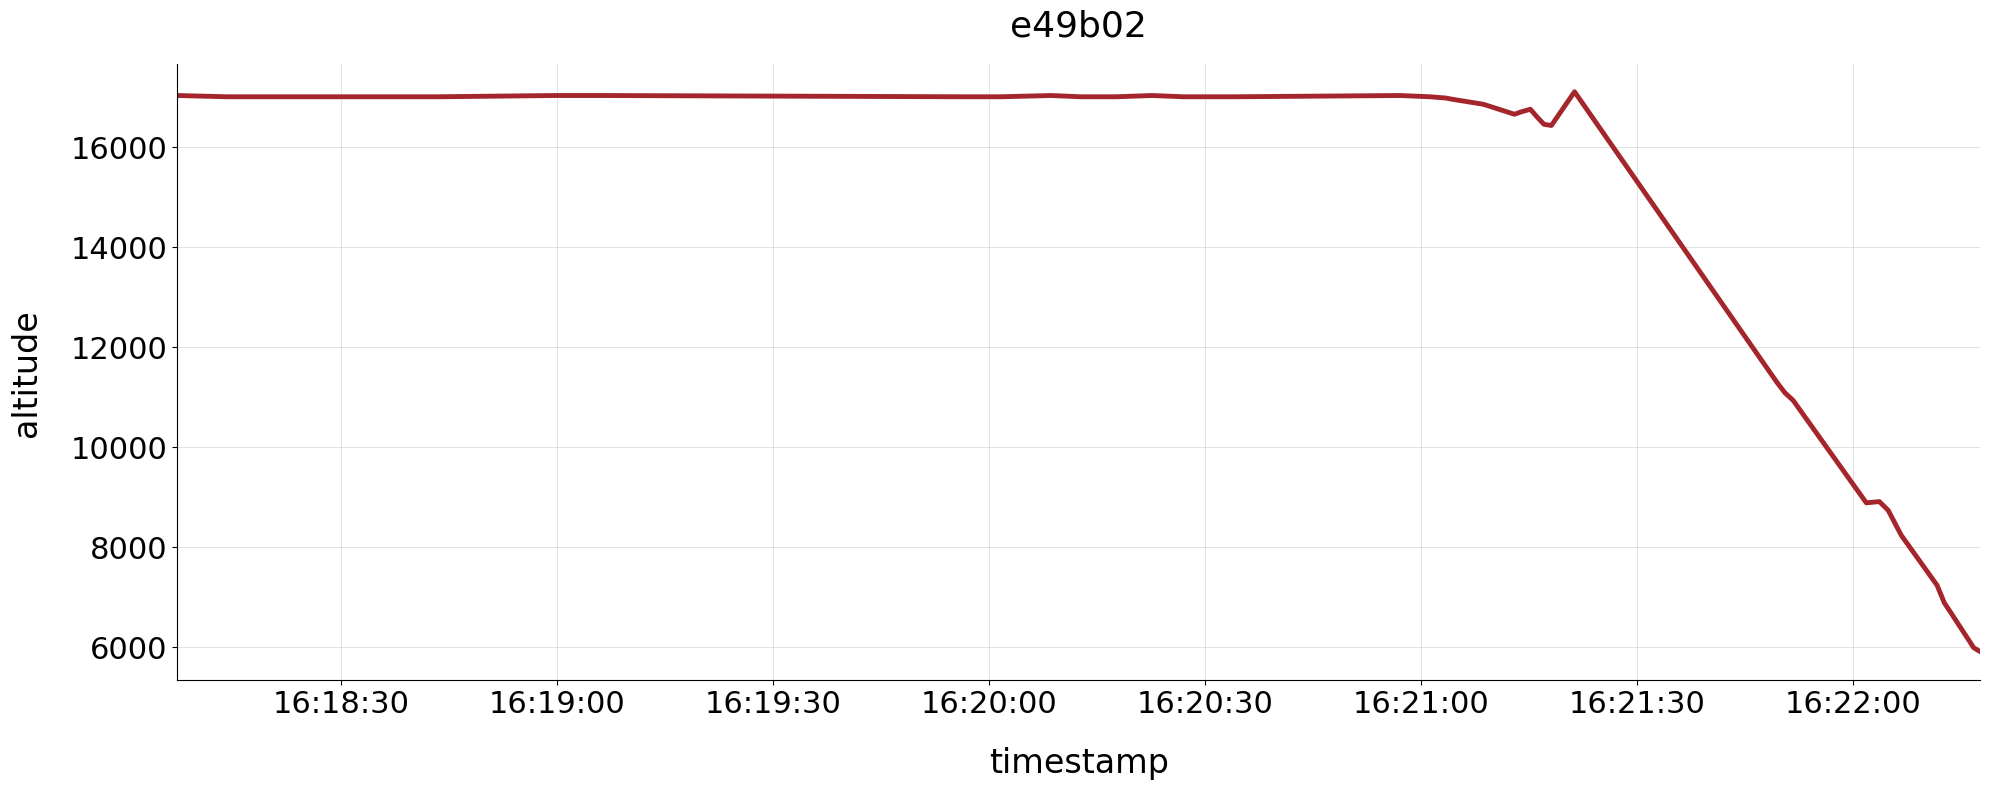

In [23]:
plot_line(flight, x="timestamp", y="altitude", title=icao)

In [24]:
from src.traces.plots_traces import *

In [25]:
title = 'Flight Trace ' +  str.upper(icao)
plot_flight_map(flight, color_cols=['altitude', 'ground_speed', 'track_degrees'], title = title)

In [26]:
num_cols = df_traj.select_dtypes(include='number').columns.tolist()
num_cols.remove("dbFlags")
num_cols.remove("flags")
num_cols.append("timestamp")
flight["time"] = flight["timestamp"].dt.strftime("%H:%M:%S")
num_cols.append("time")

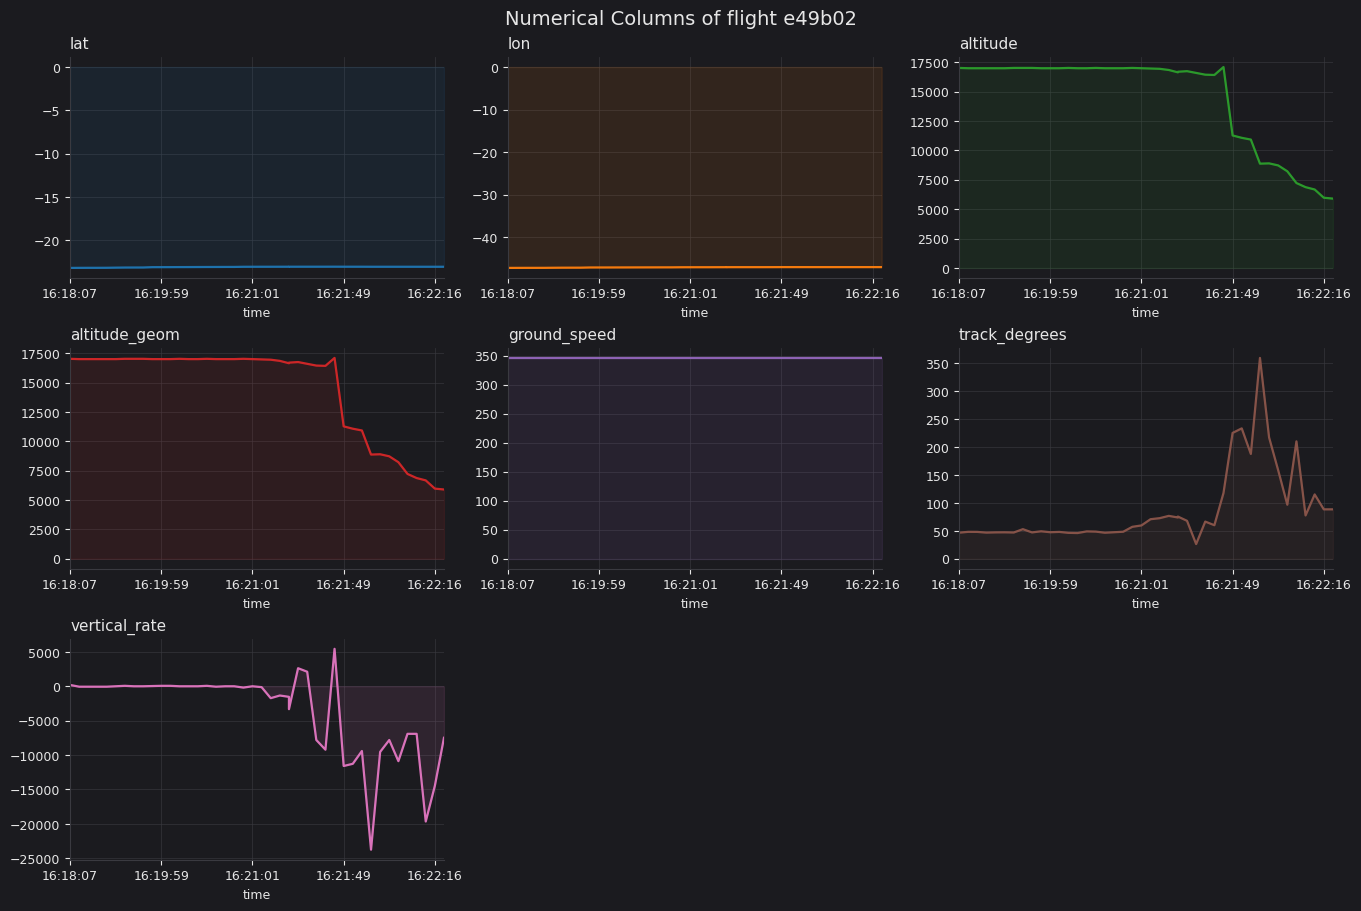

In [28]:
title = "Numerical Columns of flight " + icao
save_path = IMAGE_DIR / "num_cols_flight.png"
plot_numeric_columns(flight[num_cols], x_col="time", theme="dark", transparent=False, title = title, save_path=save_path, max_xticks=5)

#### Geographical Coverage Traces

In [26]:
print(df_traj[['lat', 'lon']].agg(['min', 'max', 'mean']))

            lat         lon
min  -37.672405 -158.487122
max   66.404626  153.627696
mean  38.249838  -45.298185



The dataset has global coverage, spanning from around -38° to +62° latitude and around
-158° to +154° longitude. The mean position at ~ 38°N / ~49°W indicates a 
concentration of flights over the North Atlantic and Americas region.

We will decode the `h3_5` field from the `trace` struct into lat/lon coordinates and plotted H3 cells as a density heatmap using Plotly. This gives us a first visual impression of where accident traces are geographically concentrated in the dataset.

Note: H3 is Uber's hexagonal geospatial indexing system that divides the world into hexagonal cells with unique IDs, at resolution 5, each cell covers ~250 km², making it useful for aggregating and visualizing spatial data.

In [ ]:
import h3
top_cells = df_traj.groupby('h3_5').size().reset_index(name='point_count').sort_values('point_count', ascending=False)

In [28]:
top_cells['lat'], top_cells['lon'] = zip(*top_cells['h3_5'].apply(lambda x: h3.cell_to_latlng(x)))

In [29]:
top_cells

,h3_5,point_count,lat,lon
3865,8526aa6ffffffff,1796,39.864528,-104.685292
7352,852f5aaffffffff,585,35.611095,139.764491
2560,851fa3d7fffffff,509,49.906250,6.147638
8623,8544c1bbfffffff,480,33.584321,-84.410919
6533,852aaab3fffffff,473,38.914737,-77.353830
...,...,...,...,...
9175,8544f613fffffff,1,29.349440,-81.088791
9178,8544f623fffffff,1,29.865703,-81.230332
486,851845a7fffffff,1,46.860709,-1.361560
490,85184613fffffff,1,47.923960,-4.529281


In [ ]:
asia = top_cells[(top_cells['lon'] > 60) & (top_cells['lon'] < 150) & 
                 (top_cells['lat'] > 0) & (top_cells['lat'] < 60)]
print(f"Asien Cells: {len(asia)}, Max point_count: {asia['point_count'].max()}")

Asien Cells: 329, Max point_count: 585


In [ ]:
top_cells['log_count'] = np.log1p(top_cells['point_count'])
plot_density(top_cells, z_col='log_count', title='Accident Flights - Point Density Map')

Distribution across hemispheres

In [68]:
total = len(df_traj)
print(f"pct_north: {(df_traj['lat'] >= 0).sum() * 100 / total:.2f}%")
print(f"pct_south: {(df_traj['lat'] <  0).sum() * 100 / total:.2f}%")
print(f"pct_east:  {(df_traj['lon'] >= 0).sum() * 100 / total:.2f}%")
print(f"pct_west:  {(df_traj['lon'] <  0).sum() * 100 / total:.2f}%")

pct_north: 95.30%
pct_south: 4.70%
pct_east:  30.78%
pct_west:  69.22%


Significant bias. ~ 95% in the Northern Hemisphere (compared to Southern Hemisphere) and around 70% in the Western Hemisphere (compared to eastern), so the dataset is clearly dominated by flights in North America and Europe, which is also reflected in the heat map.

Reasons herefore could be:
- Most of the world's air traffic happens over North America and Europe, both of which sit in the northern + western hemisphere
- ADS-B ground receiver coverage is far denser in these regions (dense networks of feeders in the US, Canada, Europe)
- Oceans in general are underrepresented since ADS-B needs ground-based receivers (or satellite coverage)

#### Temporal Analysis Accident Traces

In [ ]:
asn_accidents_filtered = import_df(PROCESSED_DIR, "asn_accident_metadata.csv")
asn_accidents_filtered.head(5)

,date,date_utc,time,time_utc,type,owner/operator,icao,registration,msn,year of manufacture,...,departure airport,destination airport,investigating agency,confidence rating,narrative,record_id,record_url,total airframe hrs,cycles,timestamp
0,Tuesday 21 March 2023,2023-03-21,15:23 LT,22:23,Boeing 777-224ER,United Airlines,aaba9a,N79011,29859/227,1999.0,...,"San Francisco International Airport, CA (SFO/K...",MÃ¼nchen-Franz Josef Strauss Airport (MUC/EDDM),NTSB,Accident investigation report completed and in...,United Airlines flight UA194 encountered conve...,309736,https://aviation-safety.net/wikibase/309736,101792 hours,NaN,2023-03-21 22:23:00+00:00
1,Wednesday 22 March 2023,2023-03-22,17:26 LT,22:26,Airbus A320-232,United Airlines,a16adc,N1902U,2714,2006.0,...,Mexico City-Benito JuÃ¡rez International Airpo...,"Houston-George Bush Intercontinental Airport, ...",NTSB,Accident investigation report completed and in...,United Airlines flight UA1091 sustained a tail...,311365,https://aviation-safety.net/wikibase/311365,22194 hours,NaN,2023-03-22 22:26:00+00:00
2,Friday 24 March 2023,2023-03-24,10:15,16:15,McDonnell Douglas MD-88 (SF),USA Jet Airlines,ab6909,N834US,53259/1849,1991.0,...,"Detroit-Willow Run Airport, MI (YIP/KYIP)",Saltillo-Plan de Guadalupe International Airpo...,NTSB,Accident investigation report completed and in...,"USA Jet Airlines, flight JUS834, sustained a t...",311093,https://aviation-safety.net/wikibase/311093,NaN,NaN,2023-03-24 16:15:00+00:00
3,Sunday 9 April 2023,2023-04-09,17:29,16:29,Boeing 737-8AS (WL),Ryanair,4ca264,EI-DHH,33817/1677,2005.0,...,Liverpool-John Lennon International Airport (L...,Dublin Airport (DUB/EIDW),AAIU,Accident investigation report completed and in...,"Ryanair flight FR5542, a Boeing 737-8AS, suffe...",310217,https://aviation-safety.net/wikibase/310217,NaN,NaN,2023-04-09 16:29:00+00:00
4,Thursday 13 April 2023,2023-04-14,c. 21,01:00,Airbus A330-243,Air Transat,c0799e,C-GUBL,728,2006.0,...,"Toronto-Pearson International Airport, ON (YYZ...","Miami International Airport, FL (MIA/KMIA)",NTSB,"Information is only available from news, socia...","Air Transat flight TS948, an Airbus A330-243 (...",318686,https://aviation-safety.net/wikibase/318686,NaN,NaN,2023-04-14 01:00:00+00:00


In [70]:
hours = pd.to_datetime(asn_accidents_filtered['time_utc'], format='%H:%M').dt.hour.value_counts().sort_index().reindex(range(24), fill_value=0)
hours.index = hours.index.astype(int)

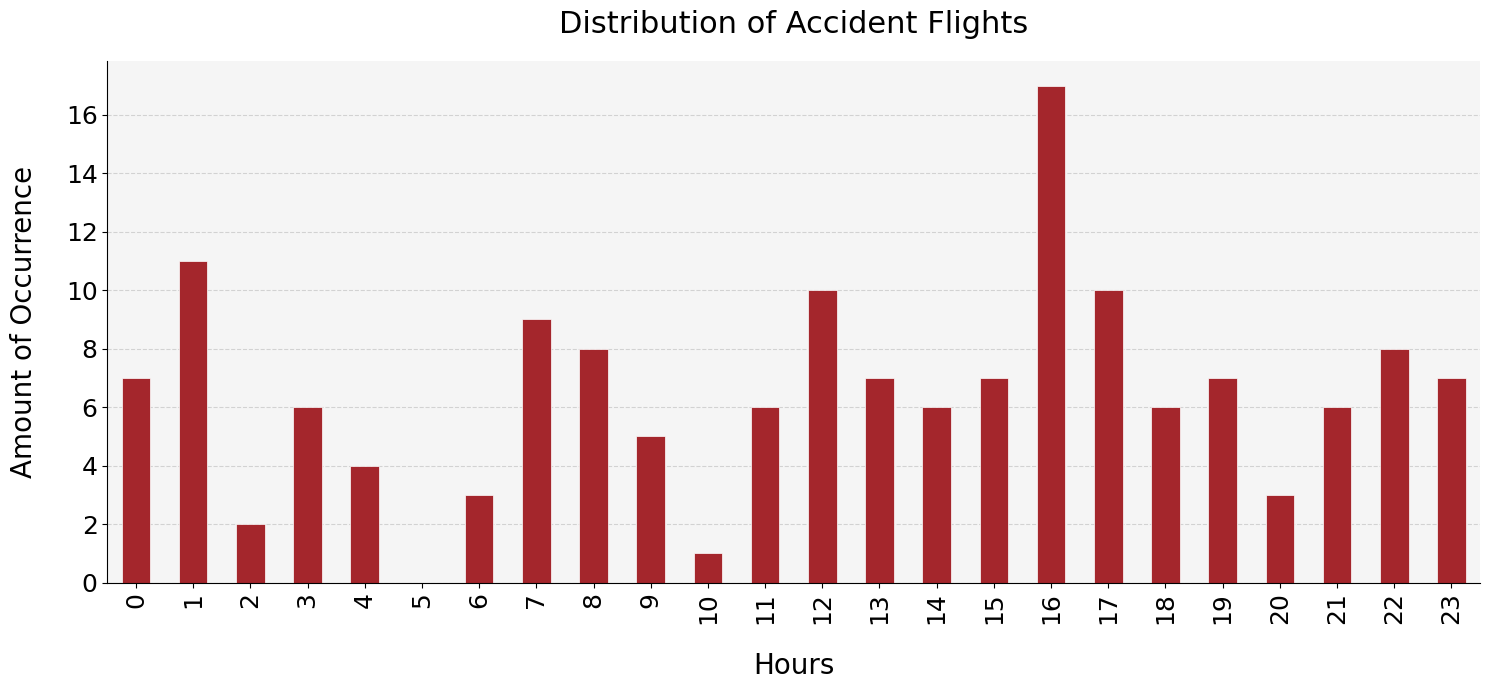

In [71]:
image_path = DESC_ANALYSIS_IMAGES / "dsitribution_accident_hours.png"
plot_bar(hours, "Distribution of Accident Flights", "Hours", "Amount of Occurrence",
         save_path = image_path, dark_mode = False)

Accidents are fairly distributed throughout the day with no extreme outliers. 
Two peaks are visible: a minor one around 07:00 UTC and a more pronounced one 
at 16:00 UTC, which roughly corresponds to peak afternoon traffic in the Americas 
(local time ~11:00-12:00 EST). The low point is around 05:00 UTC, consistent 
with reduced air traffic in the early morning hours globally.

##### Plot Features

In [ ]:
from sklearn.preprocessing import MinMaxScaler
flight[num_cols] = MinMaxScaler().fit_transform(flight[num_cols])
px_lines(flight, "timestamp", num_cols)